WALMART SALES FORECASTING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Aishwarya G Kumar\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


In [2]:
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")
test = pd.read_csv("test.csv")

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [4]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [5]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


In [7]:
train = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
train = train.merge(stores, on='Store', how='left')

test = test.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
test = test.merge(stores, on='Store', how='left')


In [8]:
# Fill missing markdown values
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

for col in markdown_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Fill remaining nulls
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

In [9]:
train.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [10]:
# Convert date
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

# Extract date features
for df in [train, test]:
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['week'] = df['Date'].dt.isocalendar().week.astype(int)

In [11]:
test.isna().sum()

Store           0
Dept            0
Date            0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
year            0
month           0
week            0
dtype: int64

In [12]:
train = pd.get_dummies(train, columns=['Type'], drop_first=True)
test = pd.get_dummies(test, columns=['Type'], drop_first=True)

In [13]:
X = train.drop(['Weekly_Sales', 'Date'], axis=1)
y = train['Weekly_Sales']

X_test = test.drop(['Date'], axis=1)

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
y_pred = model.predict(X_val)
mae_xgb = mean_absolute_error(y_val, y_pred)

print("Validation MAE:", mae_xgb)

Validation MAE: 3920.0634147508786


In [17]:
test_preds = model.predict(X_test)

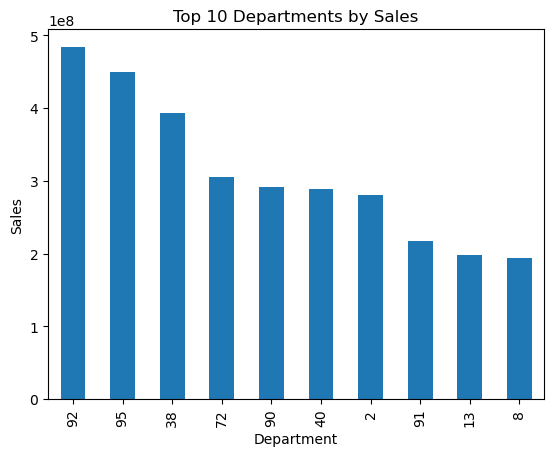

In [18]:
dept_sales = train.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
dept_sales.plot(kind='bar')
plt.title("Top 10 Departments by Sales")
plt.xlabel("Department")
plt.ylabel("Sales")
plt.show()

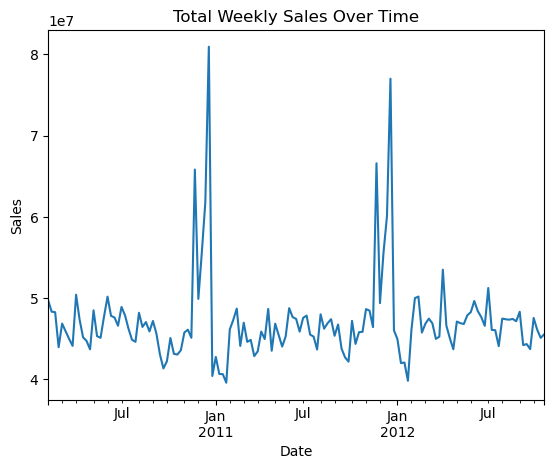

In [19]:
# Convert Date
train['Date'] = pd.to_datetime(train['Date'])

# Aggregate weekly sales
weekly_sales = train.groupby('Date')['Weekly_Sales'].sum()

plt.figure()
weekly_sales.plot()
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

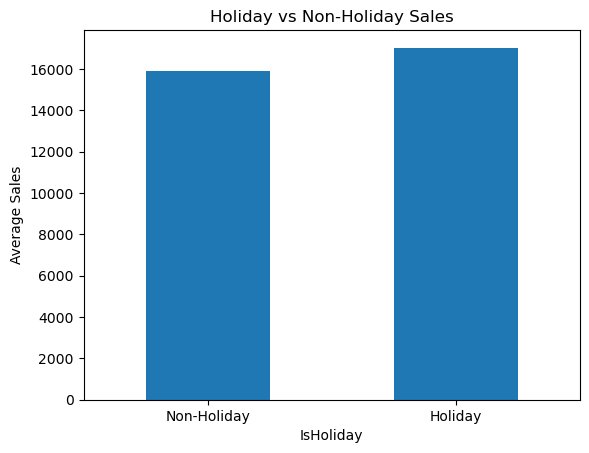

In [20]:
holiday_sales = train.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure()
holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylabel("Average Sales")
plt.show()

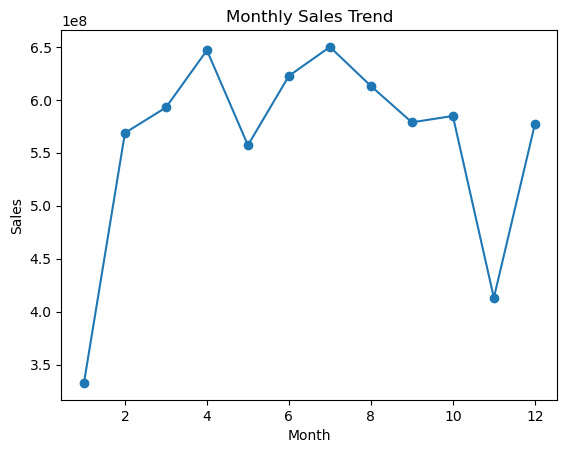

In [21]:
train['Month'] = train['Date'].dt.month

monthly_sales = train.groupby('Month')['Weekly_Sales'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [22]:
submission = pd.DataFrame({
    "Id": test['Store'].astype(str) + "_" +
          test['Dept'].astype(str) + "_" +
          test['Date'].astype(str),
    "Weekly_Sales": test_preds
})

submission.to_csv("submission.csv", index=False)

Linear Regression


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = lr_model.predict(X_val)

from sklearn.metrics import mean_absolute_error
mae_lr = mean_absolute_error(y_val, y_pred)

print("Validation MAE:", mae_lr)

Validation MAE: 14561.354166834353


In [26]:
test_preds = lr_model.predict(X_test)

In [27]:
submission = pd.DataFrame({
    "Id": test['Store'].astype(str) + "_" +
          test['Dept'].astype(str) + "_" +
          test['Date'].astype(str),
    "Weekly_Sales": test_preds
})

submission.to_csv("submission_lr.csv", index=False)

Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
rf_model = RandomForestRegressor(
    n_estimators=100,     # number of trees
    max_depth=10,         # depth of each tree
    random_state=42,
    n_jobs=-1             # use all CPU cores
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred = rf_model.predict(X_val)

from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_val, y_pred)

print("Validation MAE:", mae_rf)

Validation MAE: 4071.572936172027


In [31]:
test_preds = rf_model.predict(X_test)

In [32]:
submission = pd.DataFrame({
    "Id": test['Store'].astype(str) + "_" +
          test['Dept'].astype(str) + "_" +
          test['Date'].astype(str),
    "Weekly_Sales": test_preds
})

submission.to_csv("submission_rf.csv", index=False)

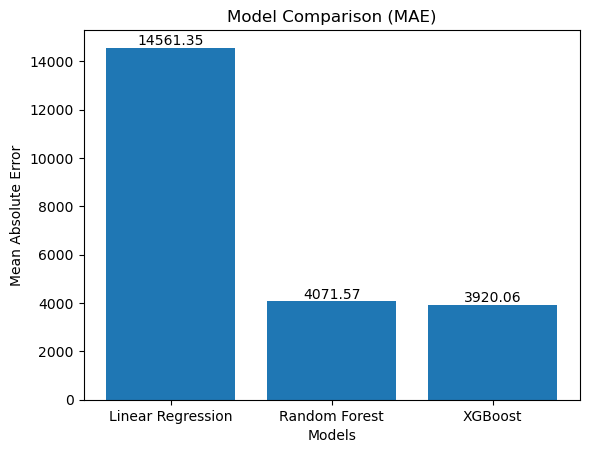

In [33]:
import matplotlib.pyplot as plt

mae_lr = mae_lr        # Linear Regression MAE
mae_rf = mae_rf        # Random Forest MAE
mae_xgb = mae_xgb      # XGBoost MAE

models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_values = [mae_lr, mae_rf, mae_xgb]

plt.figure()

bars = plt.bar(models, mae_values)

plt.title("Model Comparison (MAE)")
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2),
             ha='center', va='bottom')

plt.show()

XGBoost is the best model...MAE is accurate(Avearge mistake)